In [2]:
import os
import pandas as pd
import numpy as np

data_dir = "../data"
file_paths = {
    "presentations_df": os.path.join(data_dir, "presentations_df.csv"),
    "user_profiles": os.path.join(data_dir, "user_profiles.csv"),
    "user_profiles_flat": os.path.join(data_dir, "user_profiles_flat.csv"),
    "recommendations": os.path.join(data_dir, "recommendations.csv"),
    "ratings_matrix": os.path.join(data_dir, "ratings_matrix.csv"),
    "interaction_data": os.path.join(data_dir, "interaction_data.csv"),
    "X": os.path.join(data_dir, "X.csv"),
    "y": os.path.join(data_dir, "y.csv"),
    "feature_columns": os.path.join(data_dir, "feature_columns.txt")
}

def safe_read_csv(path, name):
    if os.path.exists(path):
        return pd.read_csv(path)
    else:
        print(f"⚠️ File not found: {name} -> {path}")
        return None

# Load all CSVs
presentations_df = safe_read_csv(file_paths["presentations_df"], "presentations_df")
user_profiles = safe_read_csv(file_paths["user_profiles"], "user_profiles")
user_profiles_flat = safe_read_csv(file_paths["user_profiles_flat"], "user_profiles_flat")
recommendations = safe_read_csv(file_paths["recommendations"], "recommendations")
ratings_matrix = safe_read_csv(file_paths["ratings_matrix"], "ratings_matrix")
interaction_data = safe_read_csv(file_paths["interaction_data"], "interaction_data")

# Load X and y
X_df = safe_read_csv(file_paths["X"], "X")
X = X_df.values if X_df is not None else None

y_df = safe_read_csv(file_paths["y"], "y")
y = y_df.values.flatten() if y_df is not None else None

# Load feature columns
if os.path.exists(file_paths["feature_columns"]):
    with open(file_paths["feature_columns"], "r") as f:
        feature_columns = [line.strip() for line in f]
else:
    print(f"⚠️ File not found: feature_columns.txt -> {file_paths['feature_columns']}")
    feature_columns = None


In [3]:
import nbimporter
from dataset_generator import prepare_recommendation_system_input_data  # use any function or class from that notebook
from utils_notebook import evaluate_regression_model 

In [4]:
user_features_names=['user_preference_Boring presentation',
 'user_preference_Graphics',
 'user_preference_Readability',
 'user_preference_Consistency',
 'user_preference_Images',
 'user_preference_Bullets',
 'user_preference_Text size',
 'user_preference_Text heavy',
 'user_preference_Tables',
 'user_preference_Agenda',
 'user_preference_Infographics',
 'user_preference_Positioning',
 'user_preference_Presentation length',
 'user_preference_General tips',
 'user_preference_Presentation skills',
 'user_preference_Powerpoint knowledge',
 'user_preference_tips and tricks',
 'user_preference_Explanation of the problem',
 'user_type_business',
 'user_type_teacher',
 'user_type_student',
 'user_type_researcher',
 'user_type_manager',
 'user_type_technical',
 'user_type_specialist',
 'presentation_type_formal_x',
 'presentation_type_creative_x',
 'presentation_type_students_x',
 'presentation_type_technical_x',
 'presentation_type_branding_x']
item_features_names=[ 'Boring presentation',
 'Graphics',
 'Readability',
 'Consistency',
 'Images',
 'Bullets',
 'Text size',
 'Text heavy',
 'Tables',
 'Agenda',
 'Infographics',
 'Positioning',
 'Presentation length',
 'General tips',
 'Presentation skills',
 'Powerpoint knowledge',
 'tips and tricks',
 'Explanation of the problem',
 'presentation_type_formal_y',
 'presentation_type_creative_y',
 'presentation_type_students_y',
 'presentation_type_technical_y',
 'presentation_type_branding_y',
 'audience_type_academic',
 'audience_type_business',
 'audience_type_kids',
 'audience_type_general',
 'audience_type_creative',
 'audience_type_specialized']


In [5]:
import numpy as np
import pandas as pd


interaction_data = interaction_data.sort_values(by=['user_id', 'article_id']).reset_index(drop=True)

def extract_time_features(dates, start_time):
    # Convert to datetime with UTC if not already
    df_temp = pd.DataFrame({'Datetime': pd.to_datetime(dates, errors='coerce')})

    # Ensure timezone awareness (UTC)
    if df_temp['Datetime'].dt.tz is None:
        df_temp['Datetime'] = df_temp['Datetime'].dt.tz_localize('UTC')
    else:
        df_temp['Datetime'] = df_temp['Datetime'].dt.tz_convert('UTC')

    # Ensure start_time is timezone-aware
    start_time = pd.to_datetime(start_time, utc=True)

    # Sort values
    df_temp = df_temp.sort_values(by='Datetime').reset_index(drop=True)

    # Extract cyclical time features
    df_temp['Hour'] = df_temp['Datetime'].dt.hour
    df_temp['Day_of_Week'] = df_temp['Datetime'].dt.dayofweek
    df_temp['Hour_sin'] = np.sin(2 * np.pi * df_temp['Hour'] / 24)
    df_temp['Hour_cos'] = np.cos(2 * np.pi * df_temp['Hour'] / 24)
    df_temp['Day_sin'] = np.sin(2 * np.pi * df_temp['Day_of_Week'] / 7)
    df_temp['Day_cos'] = np.cos(2 * np.pi * df_temp['Day_of_Week'] / 7)

    # Time since first submission in hours
    df_temp['Time_since_first_submission_hours'] = (
        (df_temp['Datetime'] - start_time).dt.total_seconds() / 3600
    ).astype(np.float32)

    return df_temp[['Hour_sin', 'Hour_cos', 'Day_sin', 'Day_cos', 'Time_since_first_submission_hours']]

# Ensure start_time is timezone-aware
start_time = pd.to_datetime("2005-12-01 00:00:00", utc=True)

# Apply time feature extraction to interaction and presentation data
time_features = extract_time_features(interaction_data['timestamp'], start_time)

user_features = interaction_data[user_features_names]
item_features = interaction_data[item_features_names]
X_user_id = interaction_data['user_id']
X_item_id = interaction_data['article_id']

# Problem features
problem_features = [
    'Boring presentation', 'Graphics', 'Readability', 'Consistency',
    'Images', 'Bullets', 'Text size', 'Text heavy', 'Tables',
    'Agenda', 'Infographics', 'Positioning'
]

# Process presentation features and timestamps
presentation_df_temp = presentations_df.sort_values(by='user_id').reset_index(drop=True)
presentation_submission_date_df = extract_time_features(presentation_df_temp['submission_date'], start_time)

# Concatenate user_id, problem features, and time features
problem_sequences_df = pd.concat(
    [presentations_df['user_id'], presentations_df[problem_features], presentation_submission_date_df],
    axis=1
)

y = interaction_data['rating']


In [11]:
interaction_data.head()


,user_id,article_id,rating,timestamp,days_since_last_rating,location,user_preference_Boring presentation,user_preference_Graphics,user_preference_Readability,user_preference_Consistency,...,presentation_type_creative_y,presentation_type_students_y,presentation_type_technical_y,presentation_type_branding_y,audience_type_academic,audience_type_business,audience_type_kids,audience_type_general,audience_type_creative,audience_type_specialized
0,1,1,4.5,2021-07-27 04:00:00+00:00,5717.1665,Illinois,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,2,3.0,2023-02-25 15:00:00+00:00,6295.6250,Illinois,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,3,4.5,2025-06-03 18:00:00+00:00,7124.7500,Illinois,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,4,3.0,2018-10-23 17:00:00+00:00,4709.7085,Illinois,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,5,3.0,2017-02-18 04:00:00+00:00,4097.1665,Illinois,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [12]:
presentations_df.head()

,Boring presentation,Graphics,Readability,Consistency,Images,Bullets,Text size,Text heavy,Tables,Agenda,Infographics,Positioning,user_id,presentation_id,submission_date
0,0,1,1,0,1,0,0,1,0,0,1,0,1,U1_P1,2021-06-10 09:00:00+00:00
1,0,0,0,0,0,0,0,0,1,0,1,0,2,U2_P2,2007-07-13 01:00:00+00:00
2,0,0,0,1,1,0,1,0,1,0,0,1,3,U3_P3,2010-08-03 01:00:00+00:00
3,1,0,1,0,0,0,0,0,0,1,1,1,3,U3_P4,2024-06-03 18:00:00+00:00
4,1,0,0,0,1,0,0,0,1,0,0,0,4,U4_P5,2010-05-26 18:00:00+00:00


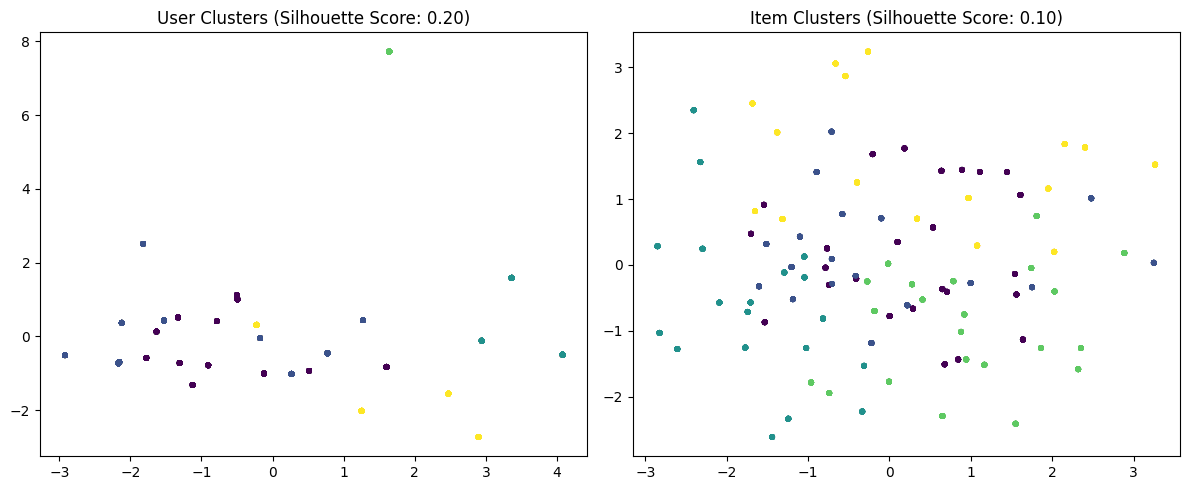

(0.20124829477455947, 0.09664124873182561)

In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import numpy as np

# Generate sample user and item feature sets (for demonstration)
np.random.seed(42)
user_features = user_features.copy()  # 500 users, 28 features
item_features = item_features.copy()  # 500 items, 30 features

# Standardize
user_scaled = StandardScaler().fit_transform(user_features)
item_scaled = StandardScaler().fit_transform(item_features)

# PCA for visualization
user_pca = PCA(n_components=2).fit_transform(user_scaled)
item_pca = PCA(n_components=2).fit_transform(item_scaled)

# KMeans clustering
k = 5
user_clusters = KMeans(n_clusters=k, random_state=42).fit_predict(user_scaled)
item_clusters = KMeans(n_clusters=k, random_state=42).fit_predict(item_scaled)

# Silhouette scores
user_sil_score = silhouette_score(user_scaled, user_clusters)
item_sil_score = silhouette_score(item_scaled, item_clusters)

# Visualization
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(user_pca[:, 0], user_pca[:, 1], c=user_clusters, cmap='viridis', s=10)
plt.title(f'User Clusters (Silhouette Score: {user_sil_score:.2f})')

plt.subplot(1, 2, 2)
plt.scatter(item_pca[:, 0], item_pca[:, 1], c=item_clusters, cmap='viridis', s=10)
plt.title(f'Item Clusters (Silhouette Score: {item_sil_score:.2f})')

plt.tight_layout()
plt.show()

(user_sil_score, item_sil_score)


In [ ]:
HEATMAP

C:\Users\maria\anaconda3\envs\tf_gpu\lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\maria\anaconda3\envs\tf_gpu\lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


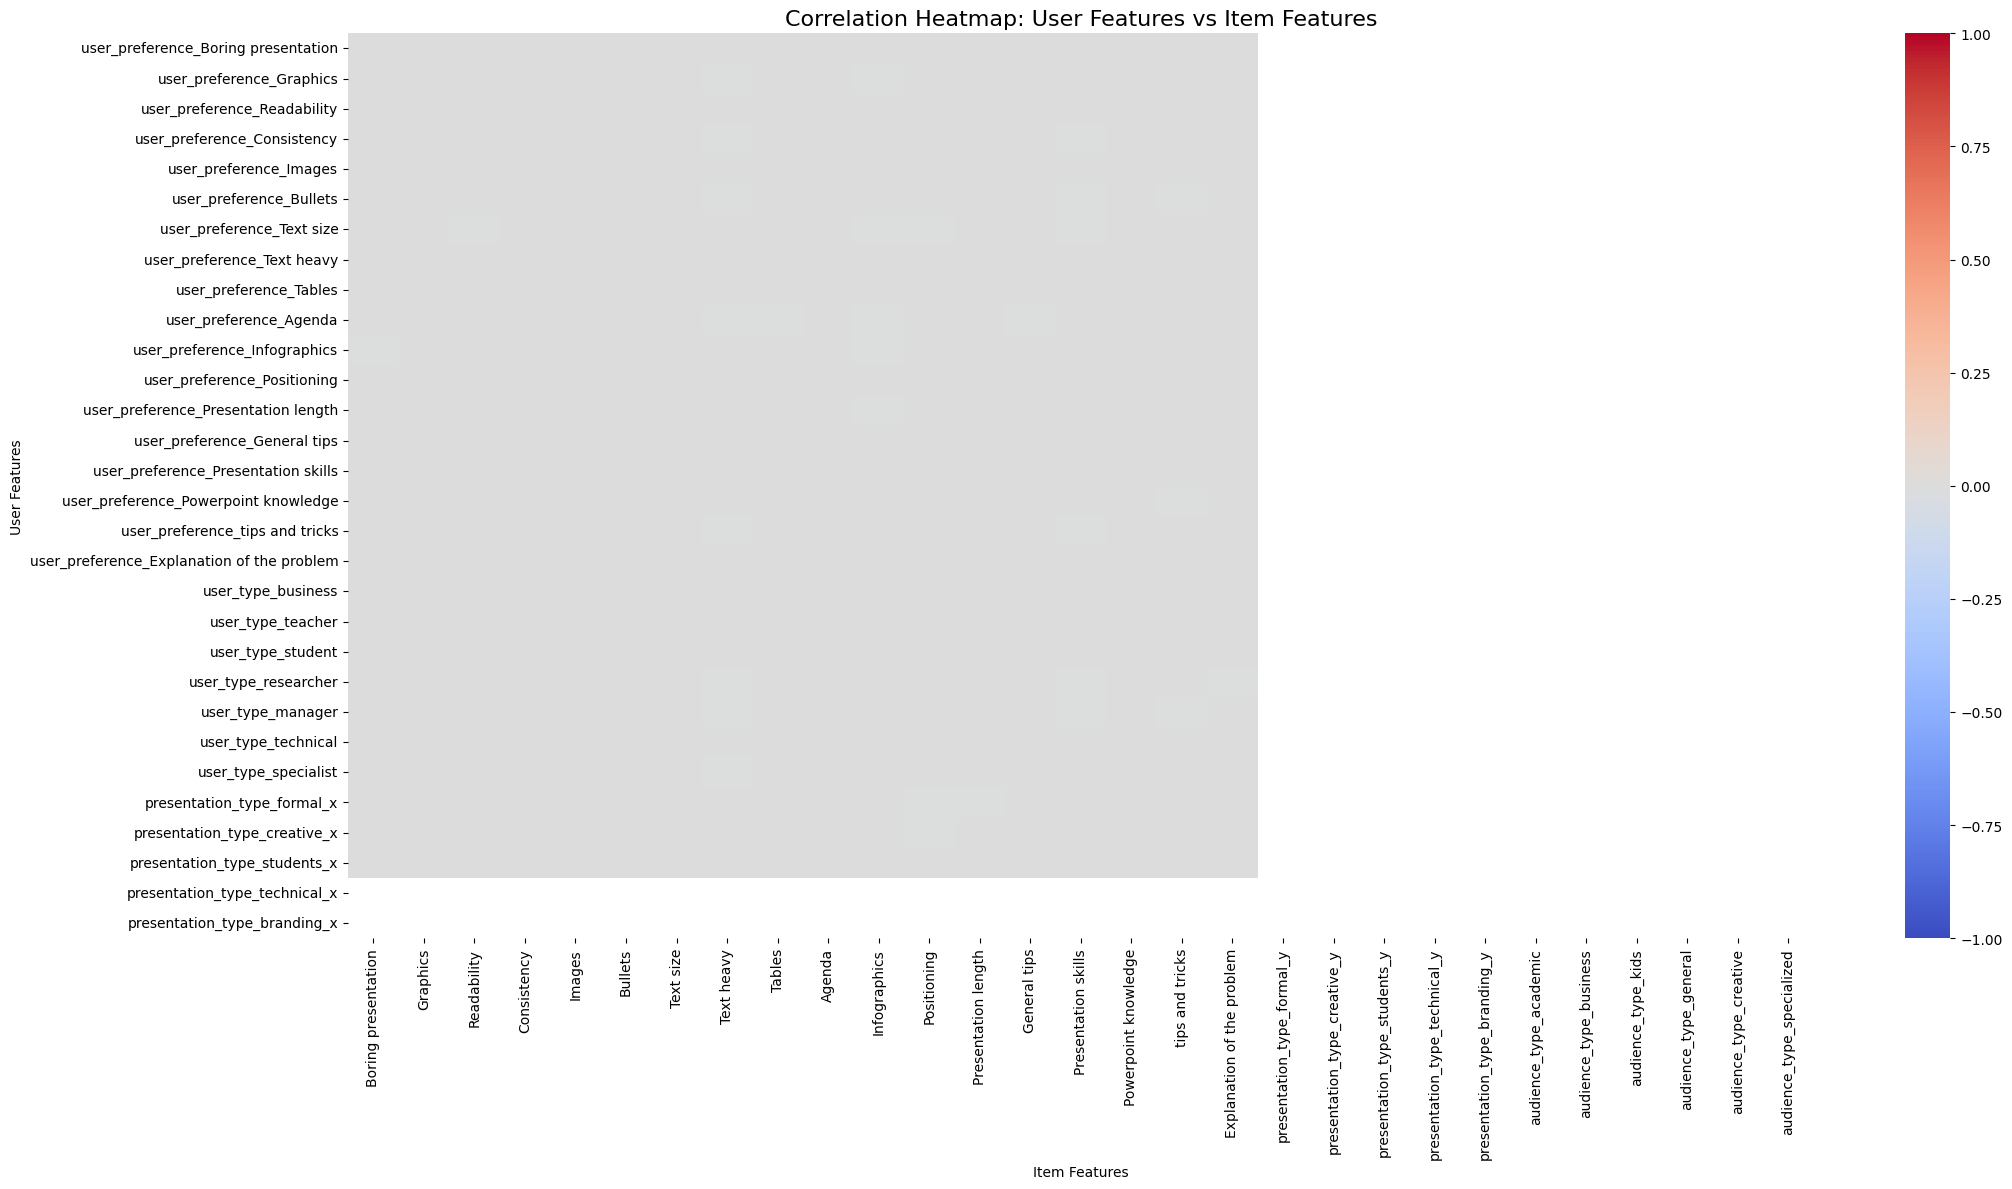

In [7]:
!pip install seaborn
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ---- Select the columns from your interaction_data DataFrame ----
user_df = interaction_data[user_features_names]
item_df = interaction_data[item_features_names]

# ---- Compute cross-correlation matrix ----
cross_corr = user_df.corrwith(item_df, axis=0, method='pearson')

# BUT corrwith works row-wise. We need full matrix:
cross_corr_matrix = pd.DataFrame(
    np.corrcoef(user_df.T, item_df.T)[:len(user_features_names), len(user_features_names):],
    index=user_features_names,
    columns=item_features_names
)

# ---- Plot heatmap ----
plt.figure(figsize=(22, 12))
sns.heatmap(
    cross_corr_matrix,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0
)
plt.title("Correlation Heatmap: User Features vs Item Features", fontsize=16)
plt.xlabel("Item Features")
plt.ylabel("User Features")
plt.tight_layout()
plt.show()


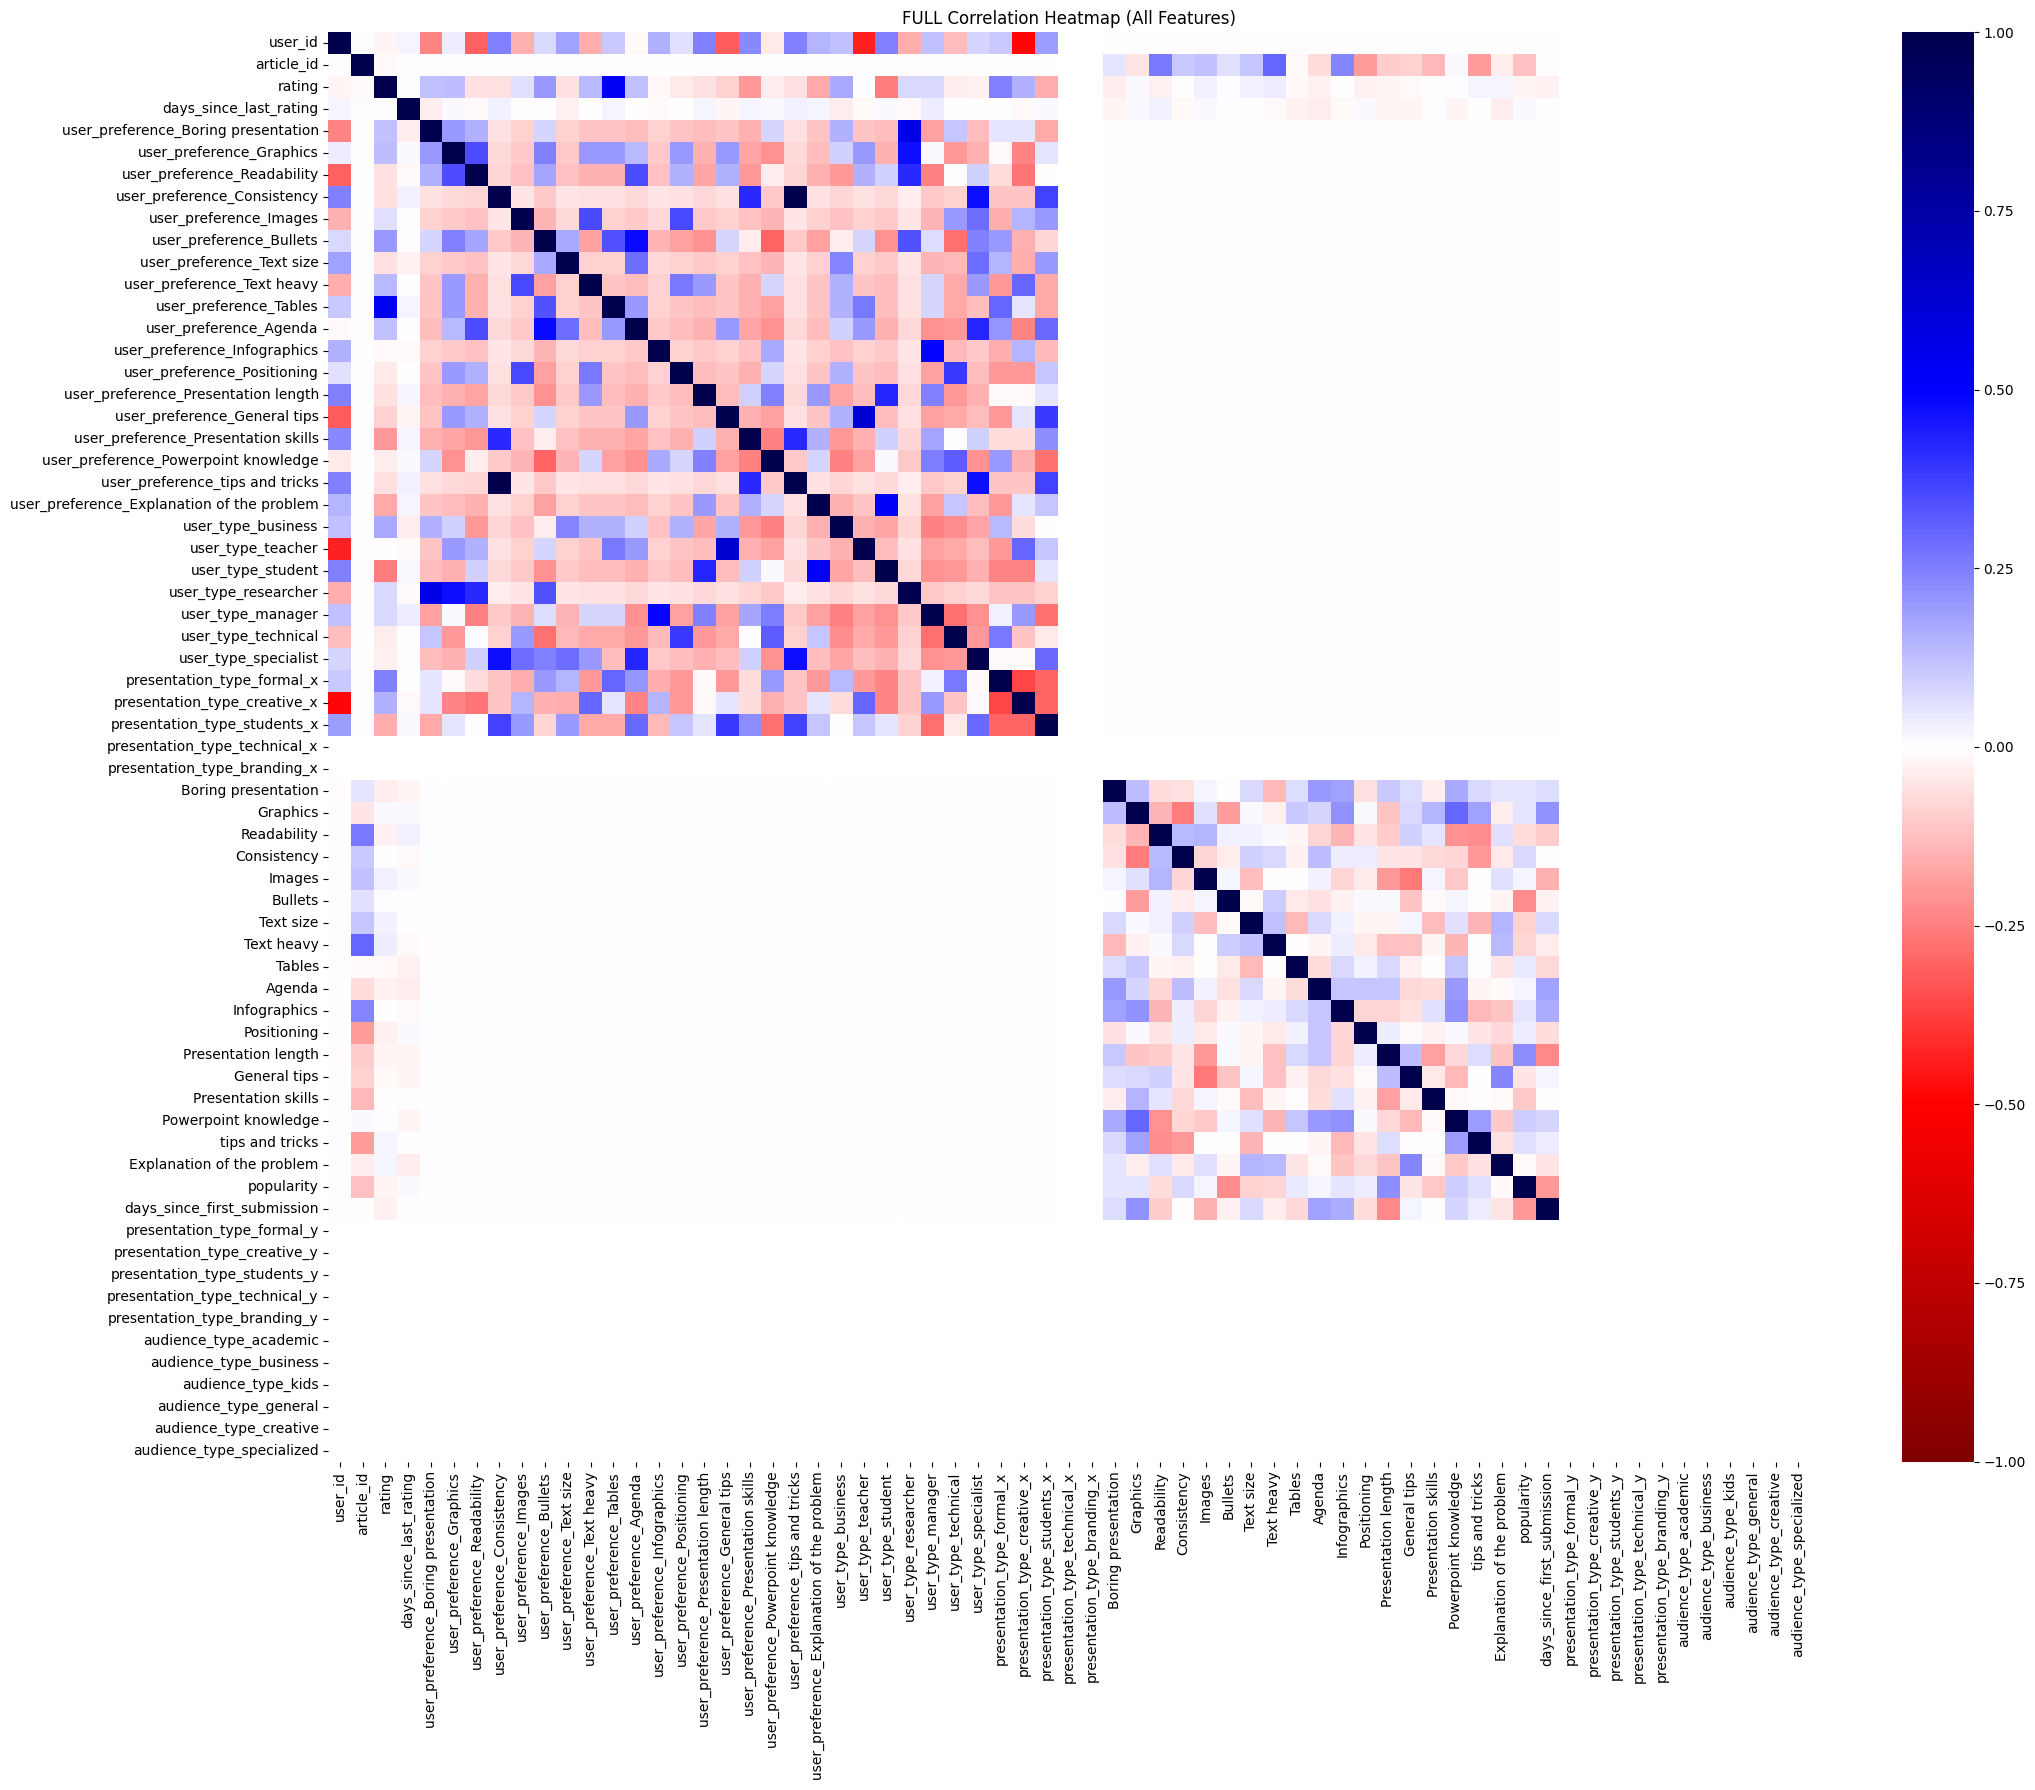

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

plt.figure(figsize=(22, 18))


interaction_data_features = interaction_data.select_dtypes(include=[np.number])

sns.heatmap(interaction_data_features.corr(), cmap="seismic_r" , vmin=-1, vmax=1)
plt.title("FULL Correlation Heatmap (All Features)")
plt.tight_layout()
plt.show()


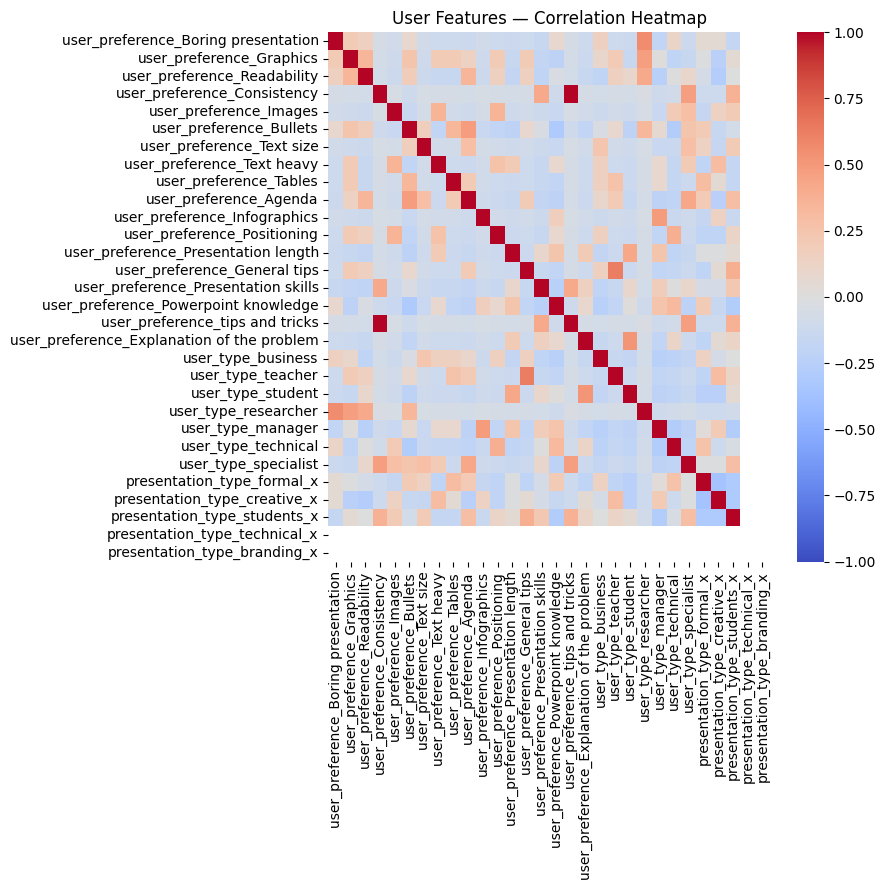

In [24]:
plt.figure(figsize=(9, 9))

sns.heatmap(user_features.corr(), cmap='coolwarm', vmin=-1, vmax=1)
plt.title("User Features — Correlation Heatmap")
plt.tight_layout()
plt.show()


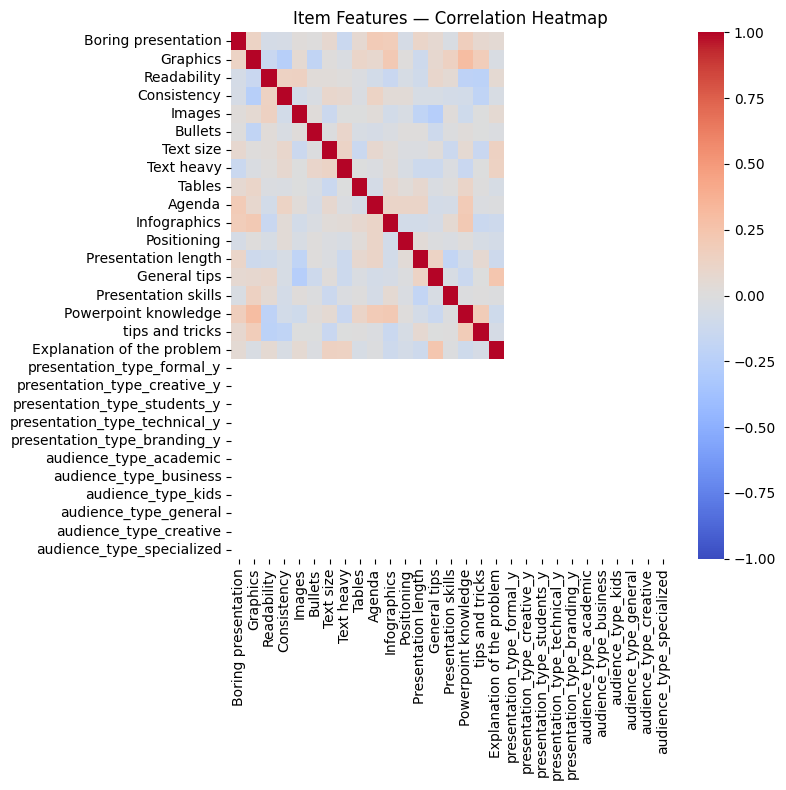

In [30]:
plt.figure(figsize=(8, 8))
sns.heatmap(item_features.corr(), cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Item Features — Correlation Heatmap")
plt.tight_layout()
plt.show()


C:\Users\maria\anaconda3\envs\tf_gpu\lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\maria\anaconda3\envs\tf_gpu\lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


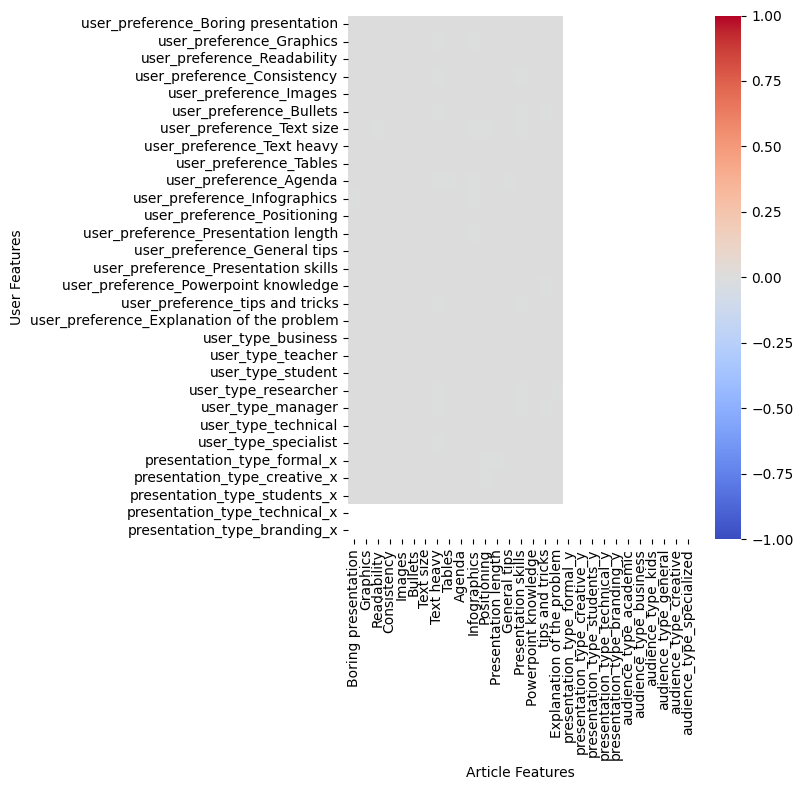

In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Select only user and item subsets
user_df = interaction_data[user_features_names]
item_df = interaction_data[item_features_names]

# Compute cross-correlation matrix
cross_corr_matrix = pd.DataFrame(
    np.corrcoef(user_df.T, item_df.T)[:len(user_features_names), len(user_features_names):],
    index=user_features_names,
    columns=item_features_names
)

plt.figure(figsize=(8, 8))
sns.heatmap(cross_corr_matrix, cmap='coolwarm', vmin=-1, vmax=1, center=0)
plt.xlabel("Article Features")
plt.ylabel("User Features")
plt.tight_layout()
plt.show()


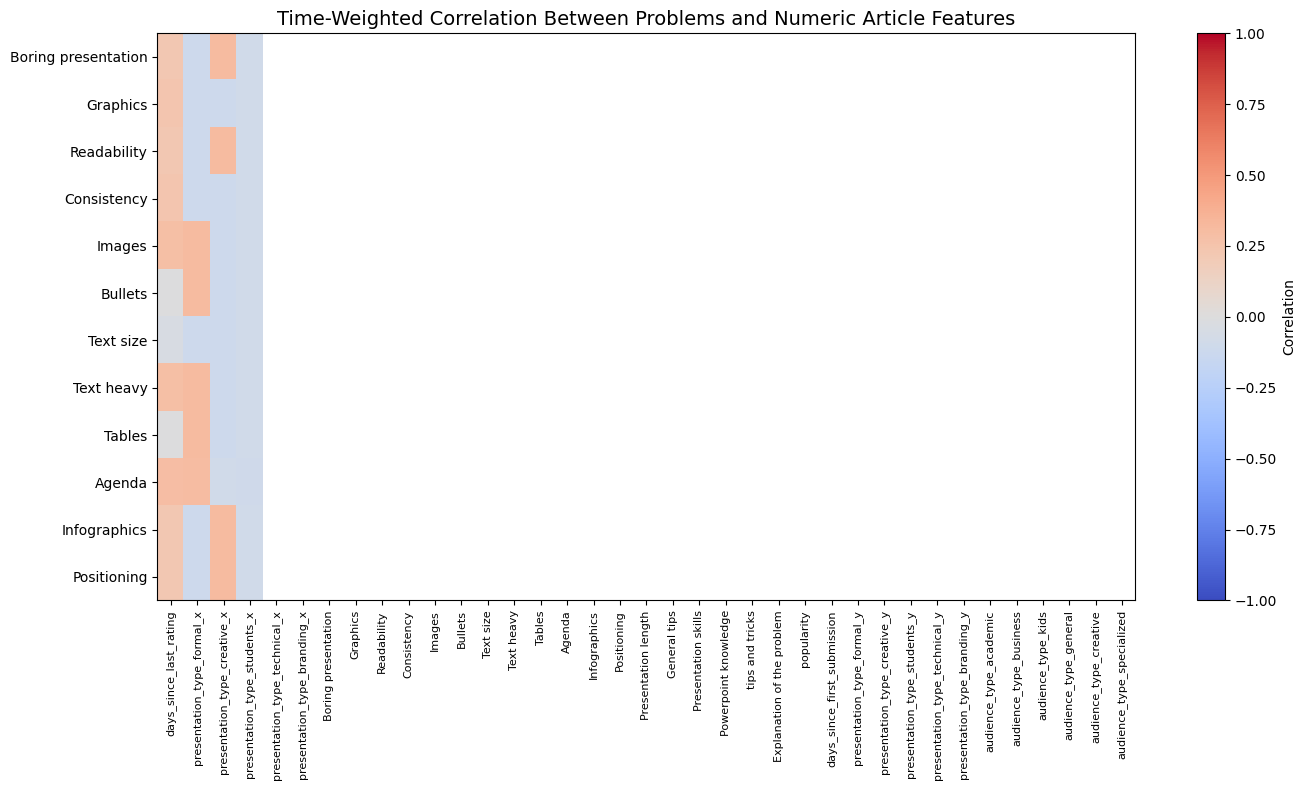

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# 1. CONFIGURATION
# -------------------------------

problem_features = [
    'Boring presentation', 'Graphics', 'Readability', 'Consistency',
    'Images', 'Bullets', 'Text size', 'Text heavy', 'Tables',
    'Agenda', 'Infographics', 'Positioning'
]

LAMBDA = 0.01  # time decay

# -------------------------------
# 2. TIME-WEIGHTED PROBLEMS
# -------------------------------

presentations_df["submission_date"] = pd.to_datetime(presentations_df["submission_date"])
max_time = presentations_df["submission_date"].max()
presentations_df["time_delta"] = (max_time - presentations_df["submission_date"]).dt.total_seconds() / 3600
presentations_df["weight"] = np.exp(-LAMBDA * presentations_df["time_delta"])

# Weighted columns
weighted_cols = [col + "_weighted" for col in problem_features]
for col in problem_features:
    presentations_df[col + "_weighted"] = presentations_df[col] * presentations_df["weight"]

# Aggregate per user
weighted_problems = presentations_df.groupby("user_id")[weighted_cols].sum().reset_index()

# -------------------------------
# 3. NUMERIC ARTICLE FEATURES
# -------------------------------

# candidate article features
article_features = [
    col for col in interaction_data.columns
    if col not in ['user_id', 'article_id', 'rating', 'timestamp', 'location']
       and not col.startswith("user_")
]

# keep only numeric columns
numeric_article_features = [
    col for col in article_features
    if pd.api.types.is_numeric_dtype(interaction_data[col])
]

user_article_feats = interaction_data.groupby("user_id")[numeric_article_features].mean().reset_index()

# -------------------------------
# 4. MERGE PROBLEMS & ARTICLE FEATURES
# -------------------------------

merged = pd.merge(weighted_problems, user_article_feats, on="user_id", how="inner")

# -------------------------------
# 5. CORRELATION MATRIX
# -------------------------------

# Use actual weighted column names
corr_matrix = merged[weighted_cols + numeric_article_features].corr()
corr_sub = corr_matrix.loc[weighted_cols, numeric_article_features]

# Optional: rename weighted_cols back for display
display_names = [col.replace("_weighted", "") for col in weighted_cols]
corr_sub.index = display_names

# -------------------------------
# 6. PLOT HEATMAP
# -------------------------------

plt.figure(figsize=(14, 8))
plt.imshow(corr_sub, aspect='auto', cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.xticks(range(len(numeric_article_features)), numeric_article_features, rotation=90, fontsize=8)
plt.yticks(range(len(display_names)), display_names, fontsize=10)
plt.title("Time-Weighted Correlation Between Problems and Numeric Article Features", fontsize=14)
plt.tight_layout()
plt.show()


In [ ]:
#### JSON generated to test the docker 

In [5]:
import pandas as pd
import json

# Load input arrays
user_features = pd.read_csv("../data/user_features_df_postman.txt").iloc[0].tolist()
item_features = pd.read_csv("../data/item_features_df_postman.txt").iloc[0].tolist()
time_features = pd.read_csv("../data/time_features_df_postman.txt").iloc[0].tolist()
problem_seq = pd.read_csv("../data/problem_seq_val_postman.txt").iloc[0].tolist()
# with open("../data/problem_seq_val_postman.txt", "r") as f:
#     problem_seq = json.load(f)[0]  # Use first row if it's a list of rows

# Build instance dictionary 00 extracted by print(model.input_names)
instance = {
    "user_feat_input": [user_features],
    "item_feat_input": [item_features],
    "time_input": [time_features],
    "problem_seq_input": [problem_seq]
}

# Write to JSON file
with open("../data/tfserving_input.json", "w") as f:
    json.dump({"instances": [instance]}, f, indent=2)

print("✅ JSON input saved to data/tfserving_input.json")



IndexError: single positional indexer is out-of-bounds

In [8]:
import pandas as pd
import numpy as np
import json


user_features = pd.read_csv("../data/user_features_df_postman.txt", header=None)
item_features = pd.read_csv("../data/item_features_df_postman.txt", header=None)
time_features = pd.read_csv("../data/time_features_df_postman.txt", header=None)
problem_seq = np.load("../data/problem_seq_val_postman.npy", allow_pickle=True)

# Confirm shapes (optional)
print("user_features shape:", user_features.shape)
print("item_features shape:", item_features.shape)
print("time_features shape:", time_features.shape)
print("problem_seq shape:", problem_seq.shape)

# Build instance — keep NumPy arrays inside
instance = {
    "user_feat_input": user_features,
    "item_feat_input": item_features,
    "time_input": time_features,
    "problem_seq_input": problem_seq
}

# Save as JSON for TensorFlow Serving
with open("../data/tfserving_input.json", "w") as f:
    json.dump({"instances": [instance]}, f, indent=2)

print("✅ JSON input saved to ../data/tfserving_input.json")


import pandas as pd
import numpy as np
import json

# Load inputs
user_features = pd.read_csv("../data/user_features_df_postman.txt", header=None)
item_features = pd.read_csv("../data/item_features_df_postman.txt", header=None)
time_features = pd.read_csv("../data/time_features_df_postman.txt", header=None)
problem_seq = np.load("../data/problem_seq_val_postman.npy", allow_pickle=True)

# Confirm shapes
print("user_features shape:", user_features.shape)
print("item_features shape:", item_features.shape)
print("time_features shape:", time_features.shape)
print("problem_seq shape:", problem_seq.shape)

# Make sure all inputs have the same number of samples
min_len = min(len(user_features), len(item_features), len(time_features), len(problem_seq))

print(min_len)

# Truncate all inputs to match the smallest length
user_features = user_features.iloc[:min_len]
item_features = item_features.iloc[:min_len]
time_features = time_features.iloc[:min_len]
problem_seq = problem_seq[:min_len]

# Convert to serializable format (lists)
instance = {
    "user_feat_input": user_features.values.tolist(),
    "item_feat_input": item_features.values.tolist(),
    "time_input": time_features.values.tolist(),
    "problem_seq_input": problem_seq.tolist()
}
 
# Convert to JSON string (for printing or use in APIs)
json_str = json.dumps({"instances": [instance]}, indent=2)

# Print it or save it
print("Instance in JSON")
print(json_str)

# Optionally, save it to a file
with open("../data/tfserving_input.json", "w") as f:
    f.write(json_str)

print("✅ JSON input saved to ../data/tfserving_input.json")



user_features shape: (101, 30)
item_features shape: (101, 29)
time_features shape: (101, 5)
problem_seq shape: (100, 12)


TypeError: Object of type DataFrame is not JSON serializable

In [9]:
import pandas as pd
import numpy as np
import json

# Load inputs
user_features = pd.read_csv("../data/user_features_df_postman.txt", header=None)
item_features = pd.read_csv("../data/item_features_df_postman.txt", header=None)
time_features = pd.read_csv("../data/time_features_df_postman.txt", header=None)
problem_seq = np.load("../data/problem_seq_val_postman.npy", allow_pickle=True)

# Print shapes for debugging
print("user_features shape:", user_features.shape)
print("item_features shape:", item_features.shape)
print("time_features shape:", time_features.shape)
print("problem_seq shape:", problem_seq.shape)

# Ensure same length
min_len = min(len(user_features), len(item_features), len(time_features), len(problem_seq))

# Truncate everything
user_features = user_features.iloc[:min_len].values.tolist()
item_features = item_features.iloc[:min_len].values.tolist()
time_features = time_features.iloc[:min_len].values.tolist()
problem_seq = problem_seq[:min_len].tolist()

# Now safely create JSON-serializable instance
instance = {
    "user_feat_input": user_features,
    "item_feat_input": item_features,
    "time_input": time_features,
    "problem_seq_input": problem_seq
}

# Convert to JSON string (for printing or use in APIs)
json_str = json.dumps({"instances": [instance]}, indent=2)

# Print it or save it
print("Instance in JSON")
print(json_str)


user_features shape: (101, 30)
item_features shape: (101, 29)
time_features shape: (101, 5)
problem_seq shape: (100, 12)
Instance in JSON
{
  "instances": [
    {
      "user_feat_input": [
        [
          "user_preference_Boring presentation",
          "user_preference_Graphics",
          "user_preference_Readability",
          "user_preference_Consistency",
          "user_preference_Images",
          "user_preference_Bullets",
          "user_preference_Text size",
          "user_preference_Text heavy",
          "user_preference_Tables",
          "user_preference_Agenda",
          "user_preference_Infographics",
          "user_preference_Positioning",
          "user_preference_Presentation length",
          "user_preference_General tips",
          "user_preference_Presentation skills",
          "user_preference_Powerpoint knowledge",
          "user_preference_tips and tricks",
          "user_preference_Explanation of the problem",
          "user_type_business",
 

In [11]:
# Optionally, save it to a file
with open("../data/tfserving_input.json", "w") as f:
    f.write(json_str)

print("✅ JSON input saved to ../data/tfserving_input.json")

✅ JSON input saved to ../data/tfserving_input.json
